## **Feature Engineering**

### **Feature Scaling**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/sample_data/Social_Network_Ads.csv")
df = df.iloc[:,2:]

df.sample(5)

,Age,EstimatedSalary,Purchased
54,27,58000,0
6,27,84000,0
194,28,89000,0
319,36,60000,0
256,41,72000,0


  <h2> <b>TRAIN TEST SPLIT</b> </h2>

In [ ]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(df.drop('Purchased' , axis = 1),
                                                       df['Purchased'],
                                                       test_size=0.3,
                                                       random_state=0)
X_train.shape,X_test.shape

((280, 2), (120, 2))

<h2> <b>StandardScaler</b> </h2>

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# use training data for scaling
scaler.fit(X_train)

# scale both training and test datasets using scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled , columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled , columns=X_test.columns)

In [ ]:
X_test_scaled

,Age,EstimatedSalary
0,-0.771013,0.497201
1,0.013305,-0.572804
2,-0.280814,0.150172
3,-0.771013,0.265849
4,-0.280814,-0.572804
...,...,...
115,1.091743,-0.139018
116,0.699584,1.769639
117,-0.672973,0.555039
118,0.797624,0.352606


In [ ]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [ ]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


 <h1> <b>Effect of Scaling</b> </h1>

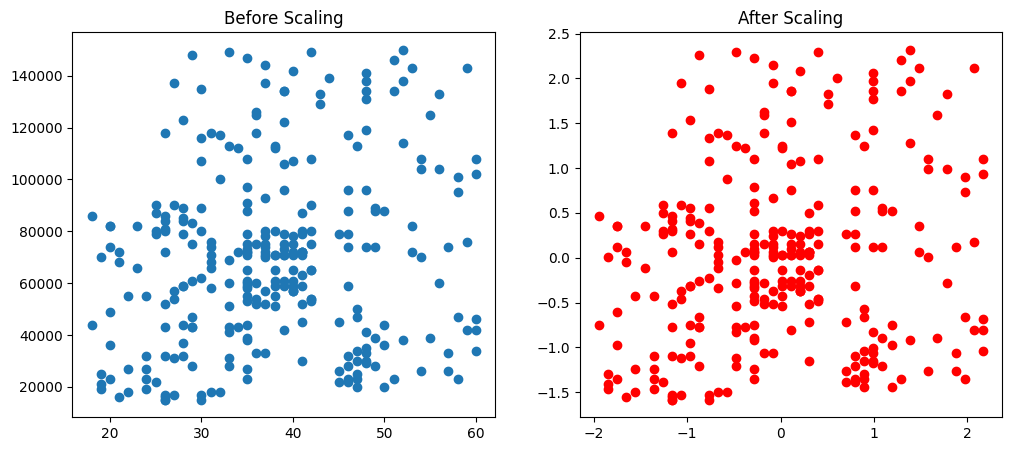

In [ ]:
fig, (ax1,ax2) = plt.subplots(ncols =2 , figsize=(12,5))
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'], color='red')
ax2.set_title("After Scaling")
plt.show()

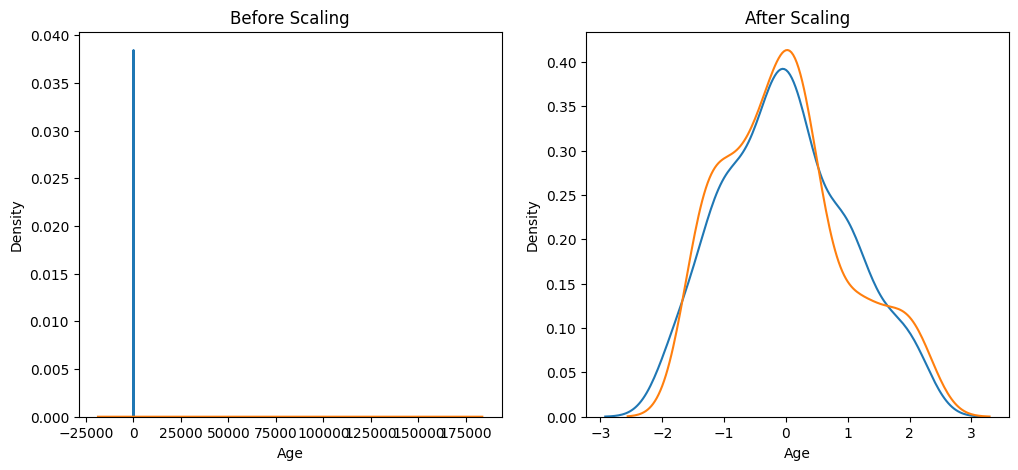

In [ ]:
fig, (ax1 , ax2) = plt.subplots(ncols = 2,figsize=(12,5))

ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Age'],ax = ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax = ax1)

ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled['Age'],ax = ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax = ax2)
plt.show()

  <h2> <b>Why Scaling??</b> </h2>

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr_scaled = LogisticRegression()


In [ ]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [ ]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


### **Normalization**

<h3><b>1. MinMaxScaling</b></h3>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/wine_data.csv',header = None , usecols=[0,1,2])
df.columns = ['Class Label' , 'Alcohol' , 'Malic Acid']
df.sample(5)

,Class Label,Alcohol,Malic Acid
158,3,14.34,1.68
113,2,11.41,0.74
105,2,12.42,2.55
3,1,14.37,1.95
157,3,12.45,3.03


<Axes: xlabel='Malic Acid', ylabel='Density'>

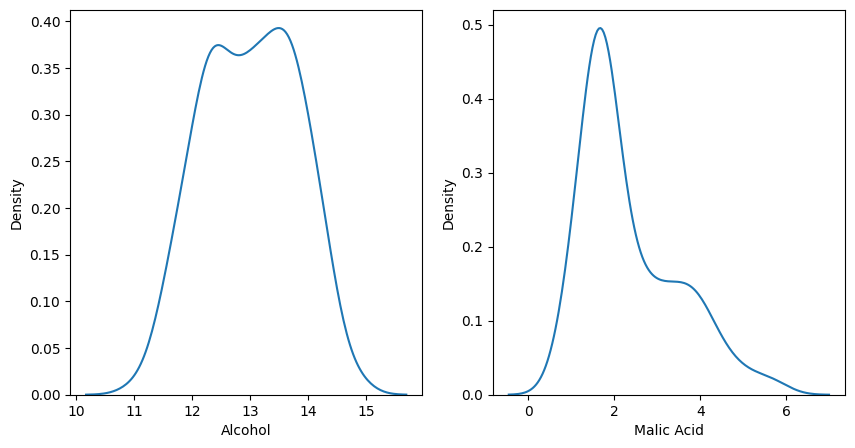

In [ ]:
fig ,(ax1,ax2) = plt.subplots(ncols = 2 ,figsize = (10,5))

sns.kdeplot(df['Alcohol'],ax = ax1)
sns.kdeplot(df['Malic Acid'],ax = ax2)

<Axes: xlabel='Class Label', ylabel='Alcohol'>

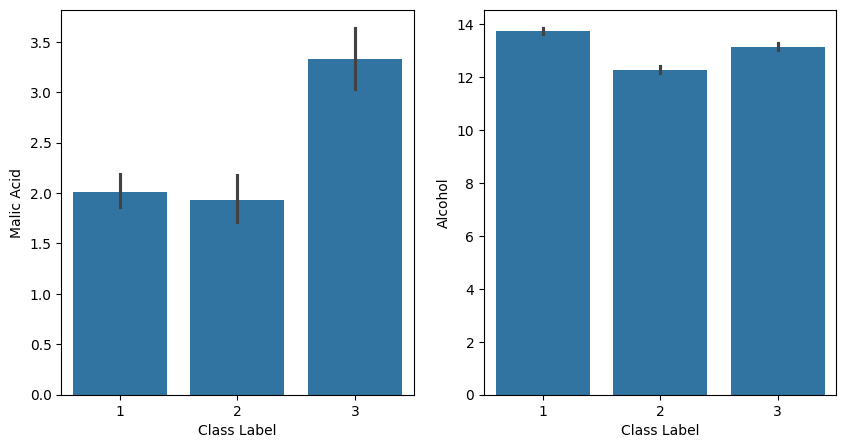

In [ ]:
fig,(ax1,ax2) = plt.subplots(ncols = 2 , figsize = (10,5))
sns.barplot(x=df['Class Label'], y= df['Malic Acid'] ,ax=ax1)
sns.barplot(x=df['Class Label'], y= df['Alcohol'] ,ax=ax2)

In [ ]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test , y_train , y_test = train_test_split(df.drop('Class Label' , axis =1),
                                                      df['Class Label'],
                                                      test_size = 0.3,
                                                      random_state =2)
X_train.shape , X_test.shape

((124, 2), (54, 2))

In [ ]:
# Scaler

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled,columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns = X_test.columns)

Text(0.5, 1.0, 'Test Data after scaling')

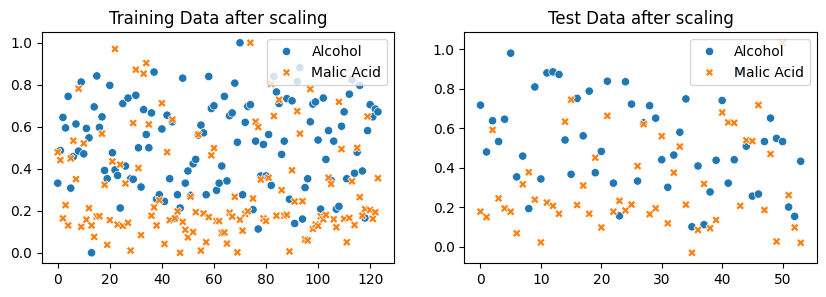

In [ ]:
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize=(10,3))
sns.scatterplot(X_train_scaled , ax=ax1)
ax1.set_title("Training Data after scaling" )
sns.scatterplot(X_test_scaled , ax =ax2)
ax2.set_title("Test Data after scaling")

<Axes: ylabel='Density'>

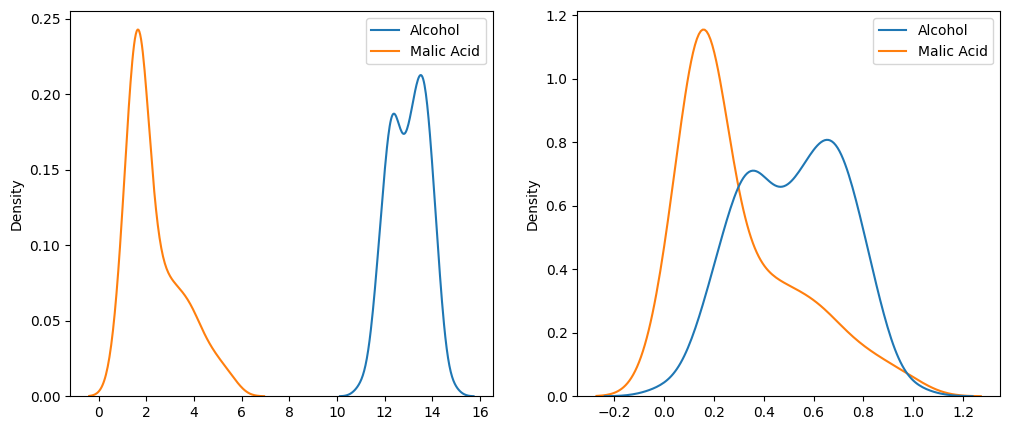

In [ ]:
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize=(12,5))
sns.kdeplot(X_train,ax = ax1)
sns.kdeplot(X_train_scaled,ax = ax2)

### **ENCODING**

<h3><b>Ordinal Encoding</b></h3>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/customer.csv')
df.sample(5)


FileNotFoundError: [Errno 2] No such file or directory: '/content/customer.csv'

In [ ]:
df = df.iloc[:,2:]

In [ ]:
df.head()

,review,education,purchased
0,Average,School,No
1,Poor,UG,No
2,Good,PG,No
3,Good,PG,No
4,Average,UG,No


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(df.iloc[:,0:2],df.iloc[:,-1],
                                                  test_size = 0.2)

In [ ]:
#X_train

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=[['Poor' , 'Average' , 'Good'],['School' , 'UG' , 'PG']])

# fitting object using training data
oe.fit(X_train)

# transforming training and test data
X_train = oe.transform(X_train)
X_test = oe.transform(X_test)

In [ ]:
#X_train

In [ ]:
oe.categories_

[array(['Poor', 'Average', 'Good'], dtype=object),
 array(['School', 'UG', 'PG'], dtype=object)]

<h3><b>Label Encoding</b></h3>
** Used when output col is categorical


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

le.fit(y_train) # using training output data to train labelencoder object

LabelEncoder()

In [ ]:
le.classes_

array(['No', 'Yes'], dtype=object)

In [ ]:
y_train = le.transform(y_train)
y_test = le.transform(y_test)

In [ ]:
y_train

array([1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0])

<h3><b>One Hot Encoding</b></h3>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful